# Predicting ArCl / AlkylCl Properties from ArBr / AlkylBr DFT Descriptors

This notebook derives linear correction factors that map computed molecular
properties from aryl/alkyl bromide substrates onto their chloride
analogues.  The same workflow was applied for aryl and alkyl halides:

1. Load matched Br / Cl training-set descriptors.
2. Fit a linear regression (Br → Cl) for each descriptor and save slope, intercept, and R².
3. Filter to high-correlation features (Pearson R > 0.95).
4. Apply the correction factors to the full Br library to generate predicted Cl descriptors.
5. Replace Br with Cl in SMILES strings and export results.



## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

from sklearn.metrics import r2_score
from scipy import stats
from rdkit import Chem

##  Aryl halides

### Load and Align Training-Set Data

Read the matched ArBr / ArCl descriptor tables, drop features that are not continuous (standard deviations, ranges, non-unique Sterimol
parameters), and match the column names by renaming _Br or _Cl to _X.

In [2]:
# Load aryl bromide and chloride training-set descriptors
df_br = pd.read_excel('./aryl/Summary_Properties_for_arbr_training_set_w_smiles_id.xlsx')
df_cl = pd.read_excel('./aryl/Summary_Properties_for_arcl_training_set_w_smiles_id.xlsx')

# Standardise identifier column names
df_br['substrate_type'] = 'arbr'
df_br.rename(columns={'Compound_Name': 'libraryID', 'id': 'libraryID',
                       'aryl_canonical': 'exp_smiles'}, inplace=True)

df_cl['substrate_type'] = 'arcl'
df_cl.rename(columns={'id': 'projectID'}, inplace=True)
df_cl['ArID'] = 'ArX-' + df_cl['projectID'].str.extract(r'(\d+)', expand=False).astype(int).astype(str).str.zfill(3)
df_cl['exp_smiles'] = df_cl['smiles']
df_cl.drop(columns=['projectID'], inplace=True)

# Remove uninformative variance / spread columns
def drop_variance_cols(df):
    to_drop = (list(df.filter(like='_stdev').columns) +
               list(df.filter(like='_range').columns) +
               list(df.filter(like='V_bur_min').columns))
    return df.drop(columns=to_drop)

df_br = drop_variance_cols(df_br)
df_cl = drop_variance_cols(df_cl)

# Harmonise halide token in column names so Br/Cl columns align
for df in (df_br, df_cl):
    df.columns = df.columns.str.replace(r'_Br_', '_X_', regex=True)
    df.columns = df.columns.str.replace(r'_Br',  '_X',  regex=True)
    df.columns = df.columns.str.replace(r'_Cl_', '_X_', regex=True)
    df.columns = df.columns.str.replace(r'_Cl',  '_X',  regex=True)

# Sterimol parameters that are constant across substrates — not useful for modelling
drop_cols_sterimol = [c for c in df_br.columns if any(
    tok in c for tok in ['Sterimol_L_C_X', 'Sterimol_B1_C_X', 'Sterimol_B5_C_X'])]

# Keep only shared columns, then drop non-unique Sterimol parameters
common_cols = df_br.columns.intersection(df_cl.columns)
df_br = df_br[common_cols].drop(columns=drop_cols_sterimol, errors='ignore')
df_cl = df_cl[common_cols].drop(columns=drop_cols_sterimol, errors='ignore')

# Restrict Br training set to substrates that have a matched Cl entry
cl_ids = df_cl['ArID'].tolist()
df_br = df_br[df_br['ArID'].isin(cl_ids)]

# Align row order
df_br = df_br.sort_values('ArID').reset_index(drop=True)
df_cl = df_cl.sort_values('ArID').reset_index(drop=True)

print(f"ArBr training set: {df_br.shape}  |  ArCl training set: {df_cl.shape}")

ArBr training set: (29, 125)  |  ArCl training set: (29, 125)


### Compute Linear Correction Factors for each feature

Linear regression was fitted using equation: `Cl = slope × Br + intercept`  

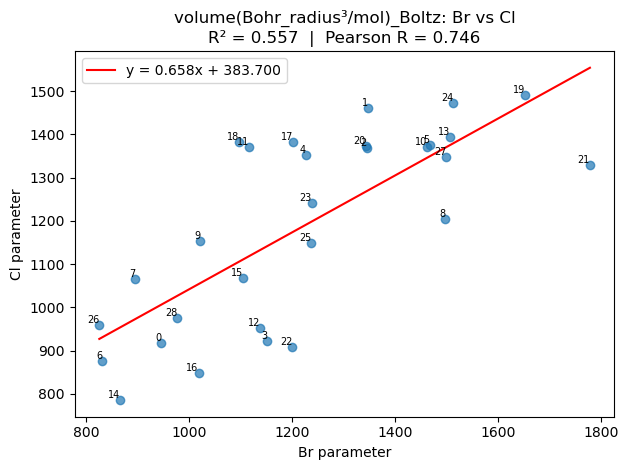

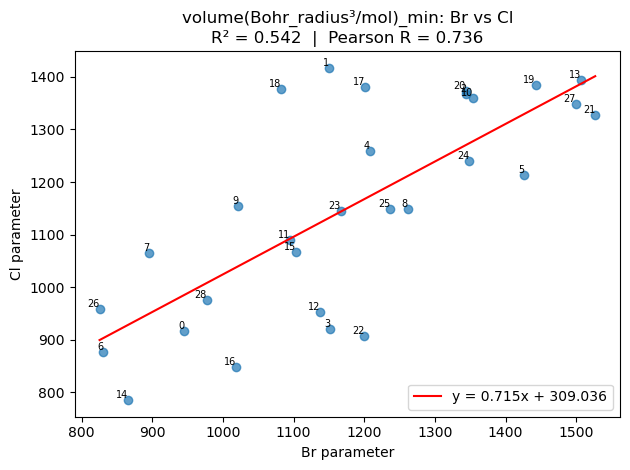

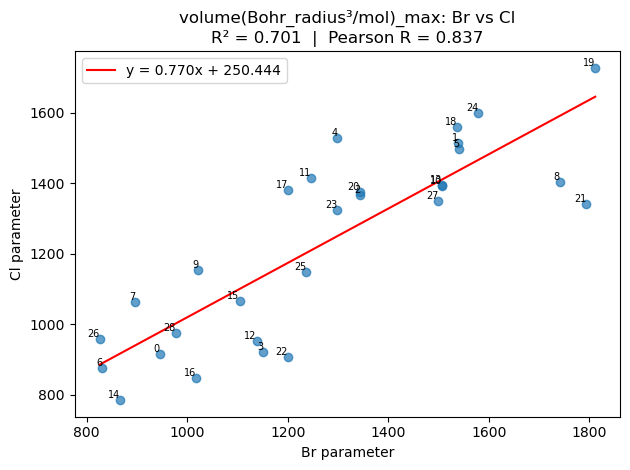

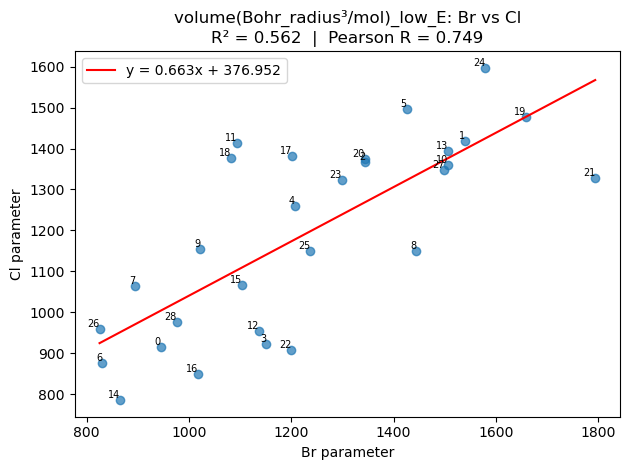

,slope,intercept,R^2,Pearson R,P value,stderr,intercept_stderr
feature,,,,,,,
HOMO_Boltz,1.104917,0.028189,0.997646,0.998823,5.024095e-37,0.010328,0.003171
HOMO_min,1.109158,0.029566,0.997651,0.998825,4.892696e-37,0.010358,0.003189
HOMO_max,1.106271,0.028577,0.997429,0.998714,1.657078e-36,0.010809,0.003317
HOMO_low_E,1.105184,0.028332,0.997835,0.998917,1.625908e-37,0.009907,0.003042
LUMO_Boltz,1.005214,0.001031,0.999797,0.999898,2.192283e-51,0.002758,0.000085
...,...,...,...,...,...,...,...
NBO_LP_occupancy_X_low_E,0.999312,-0.003887,0.994724,0.997358,2.722231e-32,0.014007,0.027136
NBO_LP_energy_X_Boltz,1.066745,-0.008669,0.995308,0.997651,5.573818e-33,0.014095,0.004969
NBO_LP_energy_X_min,1.081619,-0.003273,0.997228,0.998613,4.569889e-36,0.010974,0.003880


In [3]:
PLOT_THRESHOLD = 0.95  # show scatter plot only when Pearson R is below this

skip_cols = {'ArID', 'exp_smiles', 'smiles', 'libraryID', 'substrate_type'}
records = []

for col in df_br.columns:
    if col in skip_cols:
        continue
    res = stats.linregress(df_br[col], df_cl[col])
    records.append({
        'feature':           col,
        'slope':             res.slope,
        'intercept':         res.intercept,
        'R^2':               res.rvalue ** 2,
        'Pearson R':         res.rvalue,
        'P value':           res.pvalue,
        'stderr':            res.stderr,
        'intercept_stderr':  res.intercept_stderr,
    })

    if abs(res.rvalue) < PLOT_THRESHOLD:
        fig, ax = plt.subplots()
        ax.scatter(df_br[col], df_cl[col], alpha=0.7)
        x_line = np.linspace(df_br[col].min(), df_br[col].max(), 100)
        ax.plot(x_line, res.slope * x_line + res.intercept, 'r',
                label=f'y = {res.slope:.3f}x + {res.intercept:.3f}')
        for j in df_br.index:
            ax.text(df_br.loc[j, col], df_cl.loc[j, col], str(j),
                    fontsize=7, ha='right', va='bottom')
        ax.set(title=f'{col}: Br vs Cl\nR² = {res.rvalue**2:.3f}  |  Pearson R = {res.rvalue:.3f}',
               xlabel='Br parameter', ylabel='Cl parameter')
        ax.legend()
        plt.tight_layout()
        plt.show()

correction_term_df = pd.DataFrame(records).set_index('feature')
correction_term_df.to_excel('./aryl/output/correction_factor_information_arcl_arbr.xlsx')
display(correction_term_df)

### Filter to High-Correlation Features (Pearson R > 0.95)

Only features with a strong linear relationship between the Br and Cl training sets are used for property prediction.

In [4]:
# Reload from file so this cell is independently re-runnable
correction_term_df = pd.read_excel(
    './aryl/output/correction_factor_information_arcl_arbr.xlsx', index_col=0)

high_corr_df = correction_term_df[correction_term_df['Pearson R'] >  0.95]
low_corr_df  = correction_term_df[correction_term_df['Pearson R'] <= 0.95]

print(f"High-correlation features (R > 0.95): {len(high_corr_df)}")
print(f"Low-correlation features  (R ≤ 0.95): {len(low_corr_df)}")

display(high_corr_df)

high_corr_feats = high_corr_df.index.tolist()

High-correlation features (R > 0.95): 116
Low-correlation features  (R ≤ 0.95): 4


,slope,intercept,R^2,Pearson R,P value,stderr,intercept_stderr
feature,,,,,,,
HOMO_Boltz,1.104917,0.028189,0.997646,0.998823,5.024095e-37,0.010328,0.003171
HOMO_min,1.109158,0.029566,0.997651,0.998825,4.892696e-37,0.010358,0.003189
HOMO_max,1.106271,0.028577,0.997429,0.998714,1.657078e-36,0.010809,0.003317
HOMO_low_E,1.105184,0.028332,0.997835,0.998917,1.625908e-37,0.009907,0.003042
LUMO_Boltz,1.005214,0.001031,0.999797,0.999898,2.192283e-51,0.002758,0.000085
...,...,...,...,...,...,...,...
NBO_LP_occupancy_X_low_E,0.999312,-0.003887,0.994724,0.997358,2.722231e-32,0.014007,0.027136
NBO_LP_energy_X_Boltz,1.066745,-0.008669,0.995308,0.997651,5.573818e-33,0.014095,0.004969
NBO_LP_energy_X_min,1.081619,-0.003273,0.997228,0.998613,4.569889e-36,0.010974,0.003880


### Predict ArCl Properties for the Full Library

Apply the linear correction factors to all aryl bromide library entries to
generate predicted aryl chloride descriptors.  SMILES strings are updated by
substituting Br with Cl using RDKit.

In [5]:
# Load the full aryl-Br library
df_br_full = pd.read_excel('./molecular_descriptors.xlsx', sheet_name='arylBrlib')
df_br_full.rename(columns={'id': 'libraryID'}, inplace=True)

# Harmonise halide token and restrict to high-correlation features
df_br_full.columns = df_br_full.columns.str.replace(r'_Br_', '_X_', regex=True)
df_br_full.columns = df_br_full.columns.str.replace(r'_Br',  '_X',  regex=True)
df_br_full = df_br_full[high_corr_feats + ['libraryID', 'smiles']]

# Save Br library (with generic _X_ halide token) before transformation
df_br_to_save = df_br_full.copy()
df_br_to_save.to_excel('./aryl/output/arbr_lib_combined_high_corr_feat.xlsx', index=False)

# Apply linear correction: Cl_feature = slope * Br_feature + intercept
def apply_correction(df, correction_df, skip_cols):
    df = df.copy()
    for feat in df.columns:
        if feat in skip_cols:
            continue
        m = correction_df.loc[feat, 'slope']
        b = correction_df.loc[feat, 'intercept']
        df[feat] = m * df[feat] + b
    return df

df_cl_pred = apply_correction(df_br_full, correction_term_df,
                               skip_cols={'libraryID', 'smiles'})

# Rename columns to generic _X_ token and add Cl-specific ID column
df_cl_pred['CllibraryID'] = df_cl_pred['libraryID'].str.replace('arbr', 'arcl')
df_cl_pred.rename(columns={'libraryID': 'BrlibraryID'}, inplace=True)
df_cl_pred = df_cl_pred.copy() # to defragment  
# Replace Br with Cl in SMILES
substructure  = Chem.MolFromSmiles('Br')
cl_fragment   = Chem.MolFromSmiles('Cl')

def br_to_cl_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol and mol.HasSubstructMatch(substructure):
        mol = Chem.ReplaceSubstructs(mol, substructure, cl_fragment, replaceAll=True)[0]
        return Chem.MolToSmiles(mol)
    return smi

df_cl_pred['smiles_cl'] = df_cl_pred['smiles'].apply(br_to_cl_smiles)
df_cl_pred.rename(columns={'smiles': 'smiles_br'}, inplace=True)

df_cl_pred.to_excel('./aryl/output/arcl_lib_predicted_props_from_arbr.xlsx', index=False)
print(f"Exported {len(df_cl_pred)} rows to arcl_lib_predicted_props_from_arbr.xlsx")
display(df_cl_pred.head())

C:\Users\haruk\AppData\Local\Temp\ipykernel_21496\919022003.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cl_pred['CllibraryID'] = df_cl_pred['libraryID'].str.replace('arbr', 'arcl')


Exported 6370 rows to arcl_lib_predicted_props_from_arbr.xlsx


,HOMO_Boltz,HOMO_min,HOMO_max,HOMO_low_E,LUMO_Boltz,LUMO_min,LUMO_max,LUMO_low_E,μ_Boltz,μ_min,...,NBO_LP_occupancy_X_max,NBO_LP_occupancy_X_low_E,NBO_LP_energy_X_Boltz,NBO_LP_energy_X_min,NBO_LP_energy_X_max,NBO_LP_energy_X_low_E,BrlibraryID,smiles_br,CllibraryID,smiles_cl
0,-0.311794,-0.311722,-0.311823,-0.311734,0.016924,0.016937,0.016955,0.016964,-0.146627,-0.146564,...,1.941847,1.941783,-0.389423,-0.389335,-0.389471,-0.389391,arbr141,Cc1[nH]nc(C(F)(F)F)c1Br,arcl141,Cc1[nH]nc(C(F)(F)F)c1Cl
1,-0.279210,-0.279013,-0.279199,-0.279142,0.003524,0.003542,0.003543,0.003548,-0.138172,-0.138090,...,1.947127,1.947020,-0.380537,-0.380326,-0.380573,-0.380455,arbr142,Cc1[nH]nc(-c2ccccc2)c1Br,arcl142,Cc1[nH]nc(-c2ccccc2)c1Cl
2,-0.285431,-0.285258,-0.285427,-0.285364,0.015909,0.015922,0.015939,0.015947,-0.134672,-0.134582,...,1.936163,1.936147,-0.371437,-0.371099,-0.371462,-0.371306,arbr143,Cc1cc(C(C)(C)C)cc(C)c1Br,arcl143,Cc1cc(C(C)(C)C)cc(C)c1Cl
3,-0.305595,-0.305500,-0.305616,-0.305534,0.000207,0.000225,0.000222,0.000227,-0.152392,-0.152343,...,1.928646,1.928692,-0.380569,-0.380358,-0.380605,-0.380488,arbr145,Cc1cccc(Cl)c1Br,arcl145,Cc1cccc(Cl)c1Cl
4,-0.305717,-0.305622,-0.305738,-0.305655,0.002107,0.002125,0.002124,0.002129,-0.151461,-0.151409,...,1.932979,1.932989,-0.380963,-0.380758,-0.381000,-0.380885,arbr146,Cc1cccc(F)c1Br,arcl146,Cc1cccc(F)c1Cl


## Alkyl halides

### Load and Align Training-Set Data

In [3]:
df_br = pd.read_excel('./alkyl/Summary_Properties_for_alkylBr_w_smiles.xlsx')
df_cl = pd.read_excel('./alkyl/Summary_Properties_for_alkylCl_w_smiles.xlsx')

# Drop uninformative variance / spread columns
def drop_variance_cols_alkyl(df):
    to_drop = (list(df.filter(like='_stdev').columns) +
               list(df.filter(like='_range').columns))
    return df.drop(columns=to_drop)

df_br = drop_variance_cols_alkyl(df_br)
df_cl = drop_variance_cols_alkyl(df_cl)

# Sterimol B1 parameters are constant (not unique) across substrates
sterimol_to_drop = [c for c in df_br.columns if any(
    tok in c for tok in [
        'Sterimol_B1_C_X', 'Sterimol_B1_X_C',
        'Buried_Sterimol_B1_C_X', 'Buried_Sterimol_B1_X_C',
        'Buried_Sterimol_B5_X_C',
    ])]

df_br = df_br.drop(columns=sterimol_to_drop, errors='ignore')
df_cl = df_cl.drop(columns=sterimol_to_drop, errors='ignore')

# Numeric sort key derived from the molecule ID
df_br['numeric_id'] = df_br['id'].str.replace('mol',   '', regex=False).astype(int)
df_cl['numeric_id'] = df_cl['id'].str.replace('molCl', '', regex=False).astype(int)

df_br = df_br.sort_values('numeric_id').reset_index(drop=True)
df_cl = df_cl.sort_values('numeric_id').reset_index(drop=True)

# Confirm column alignment
only_br = set(df_br.columns) - set(df_cl.columns)
only_cl = set(df_cl.columns) - set(df_br.columns)
print(f"Columns only in Br: {only_br}")
print(f"Columns only in Cl: {only_cl}")
print(f"AlkBr: {df_br.shape}  |  AlkCl: {df_cl.shape}")

Columns only in Br: set()
Columns only in Cl: set()
AlkBr: (27, 179)  |  AlkCl: (27, 179)


### Compute Linear Correction Factors for each features

Low-correlation feature: μ_Boltz  (R = 0.937)


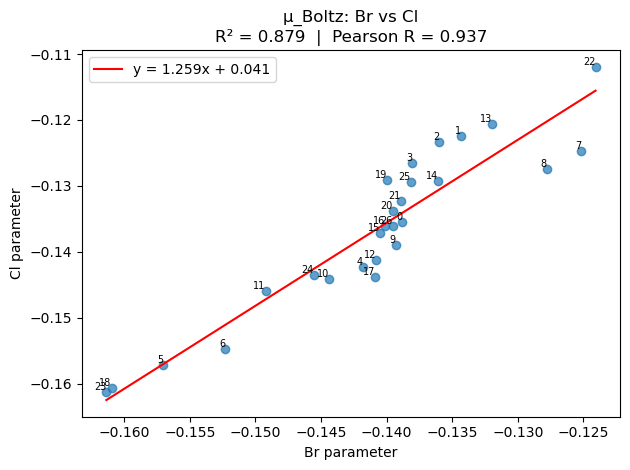

Low-correlation feature: μ_min  (R = 0.940)


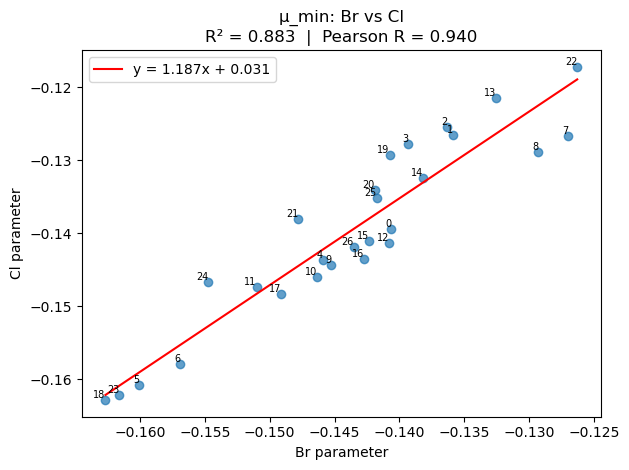

Low-correlation feature: μ_max  (R = 0.910)


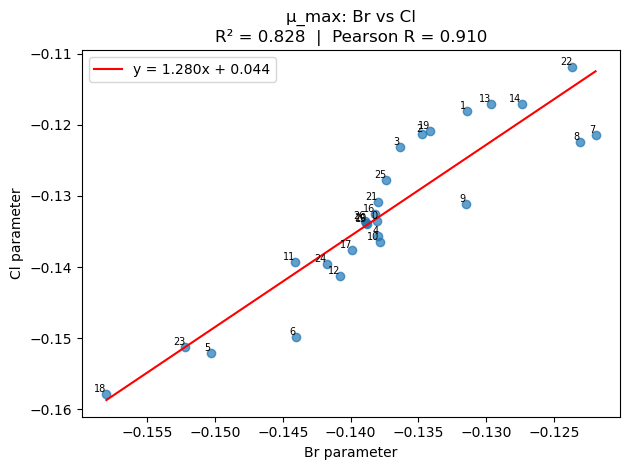

Low-correlation feature: μ_low_E  (R = 0.940)


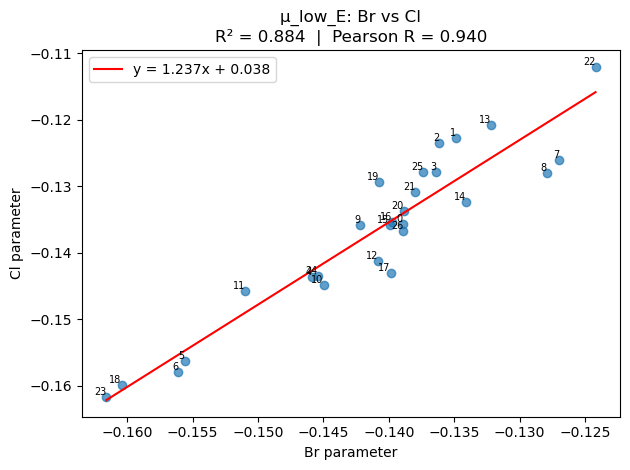

Low-correlation feature: ω_min  (R = 0.940)


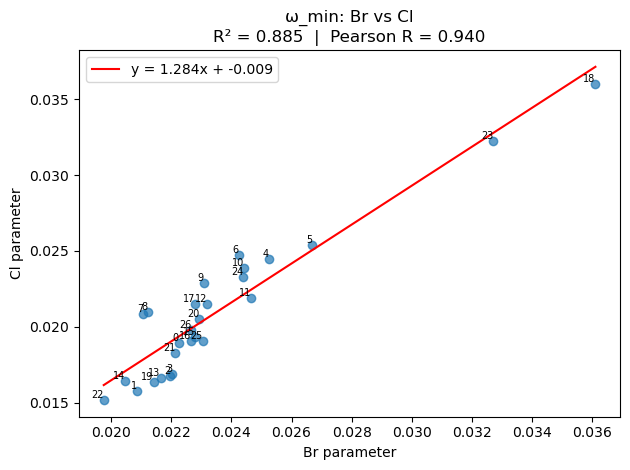

Low-correlation feature: polar_aniso(Debye)_low_E  (R = 0.836)


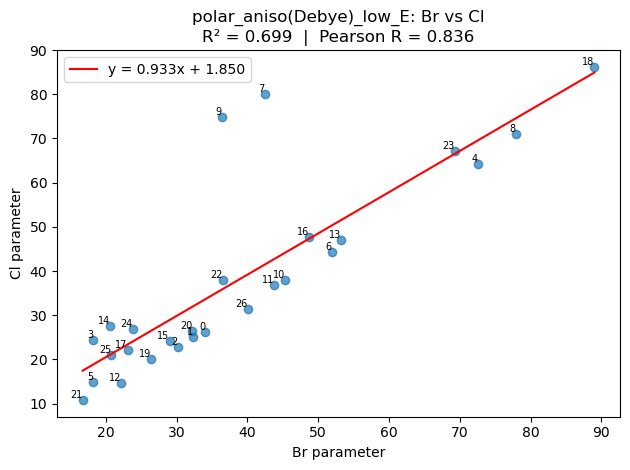

Low-correlation feature: dipole(Debye)_low_E  (R = 0.925)


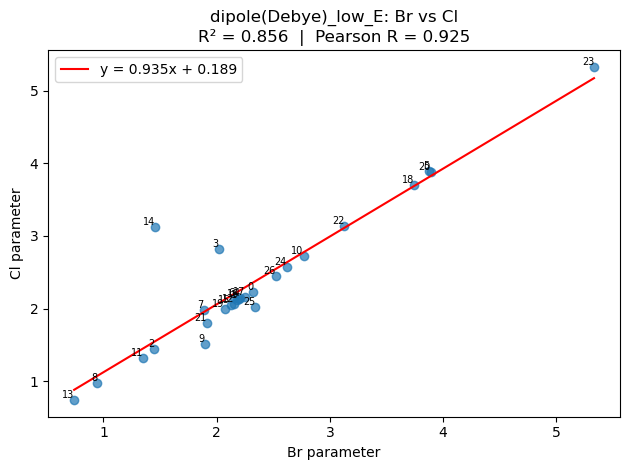

Low-correlation feature: volume(Bohr_radius³/mol)_Boltz  (R = 0.920)


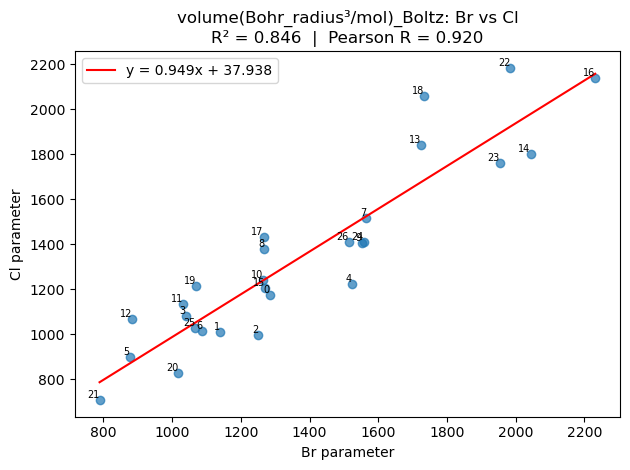

Low-correlation feature: volume(Bohr_radius³/mol)_min  (R = 0.930)


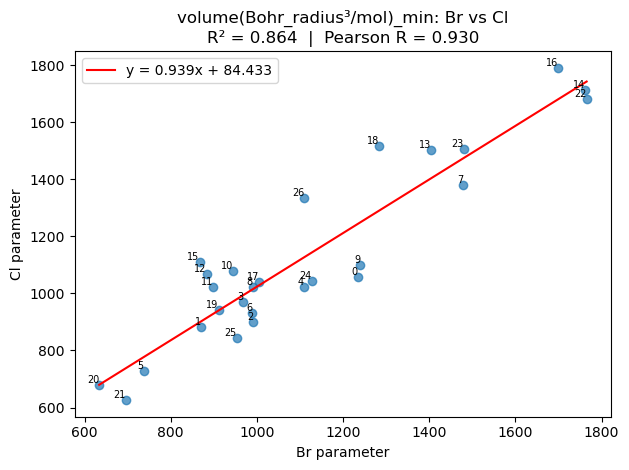

Low-correlation feature: volume(Bohr_radius³/mol)_max  (R = 0.917)


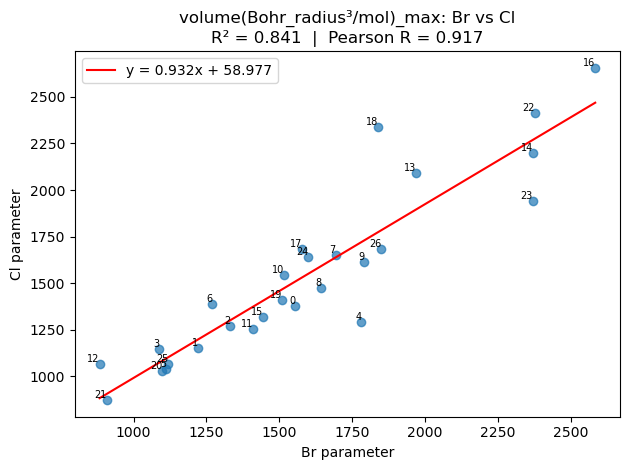

Low-correlation feature: volume(Bohr_radius³/mol)_low_E  (R = 0.846)


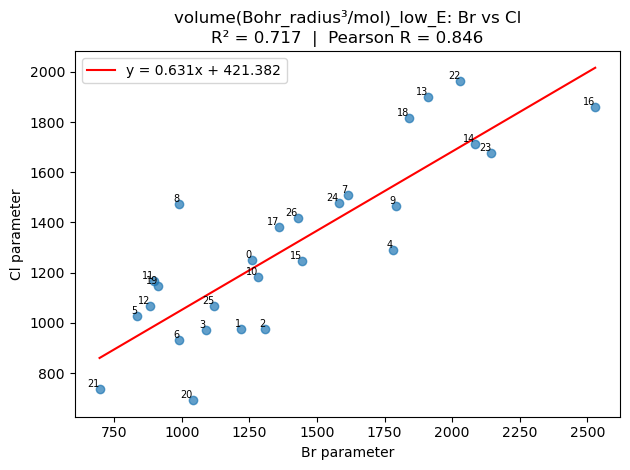

Low-correlation feature: NBO_charge_X_low_E  (R = 0.942)


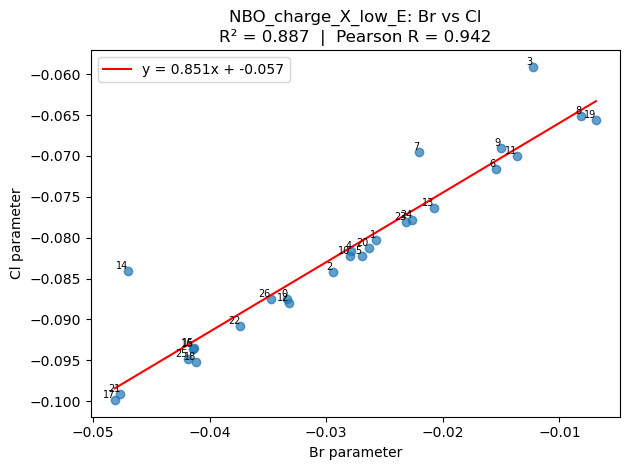

Low-correlation feature: NMR_shift_X_low_E  (R = 0.939)


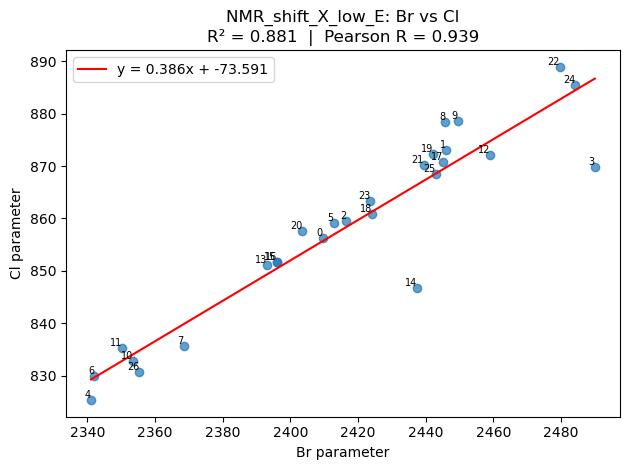

Low-correlation feature: %Vbur_C_2.0Å_max  (R = 0.931)


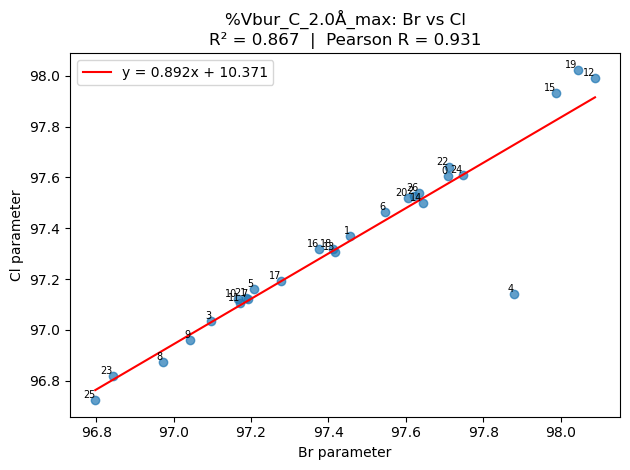

Low-correlation feature: %Vbur_X_2.0Å_low_E  (R = 0.897)


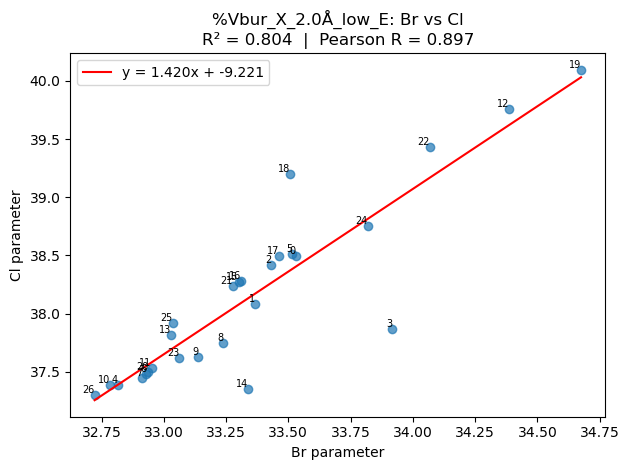

Low-correlation feature: %Vbur_X_2.5Å_low_E  (R = 0.799)


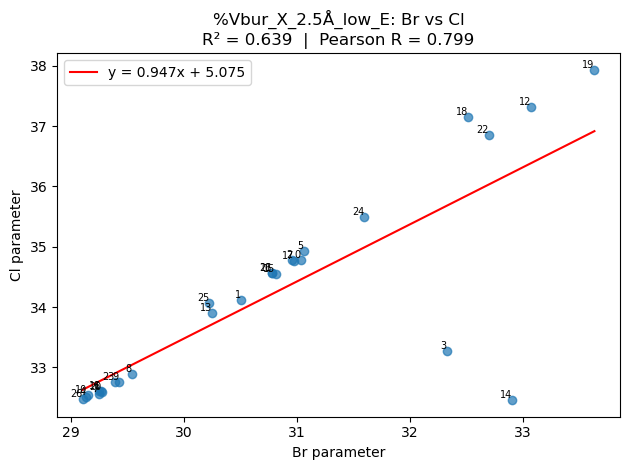

Low-correlation feature: %Vbur_X_3.0Å_low_E  (R = 0.745)


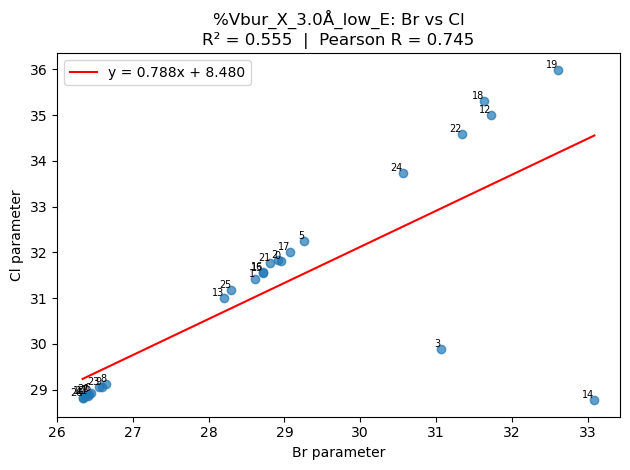

Low-correlation feature: %Vbur_X_3.5Å_low_E  (R = 0.735)


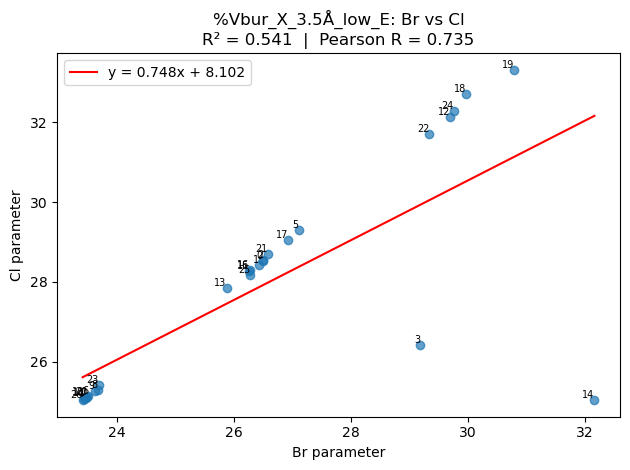

Low-correlation feature: %Vbur_X_4.0Å_low_E  (R = 0.746)


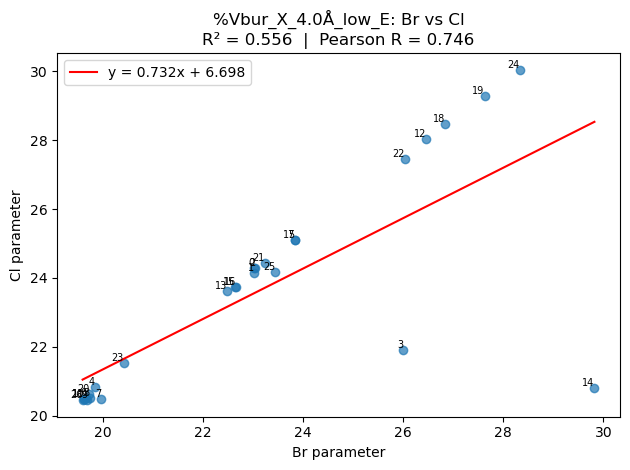

Low-correlation feature: Sterimol_L_X_C(Å)_morfeus_low_E  (R = 0.744)


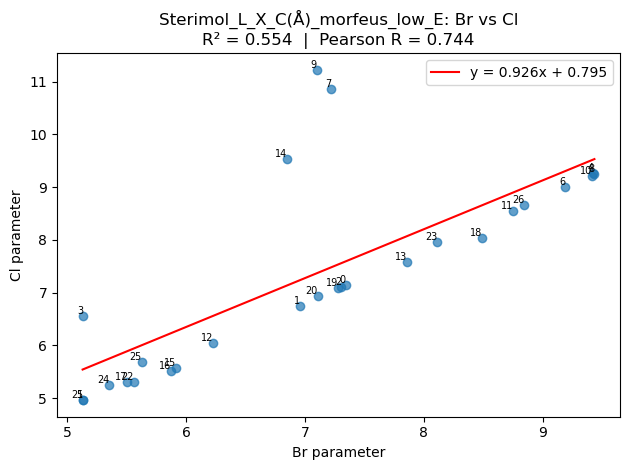

Low-correlation feature: Buried_Sterimol_L_C_X_5.0(Å)_Boltz  (R = 0.852)


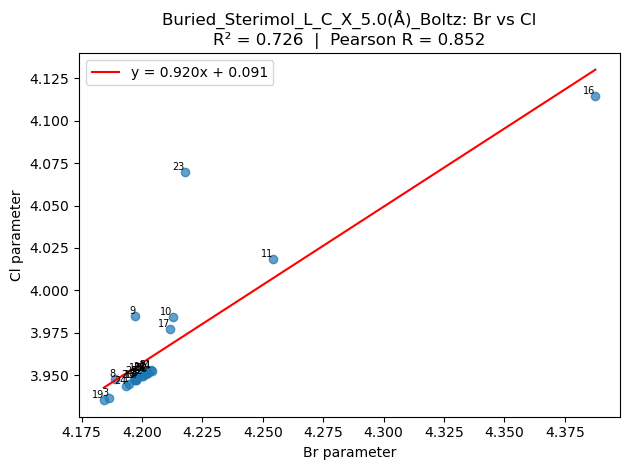

Low-correlation feature: Buried_Sterimol_B5_C_X_5.0(Å)_low_E  (R = 0.824)


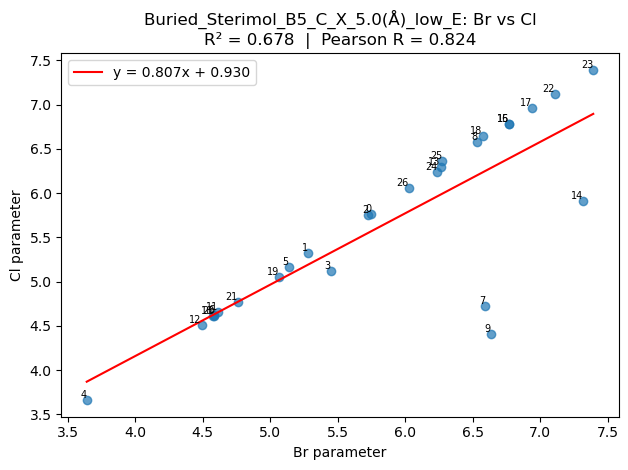

Low-correlation feature: Buried_Sterimol_L_X_C_5.0(Å)_max  (R = 0.809)


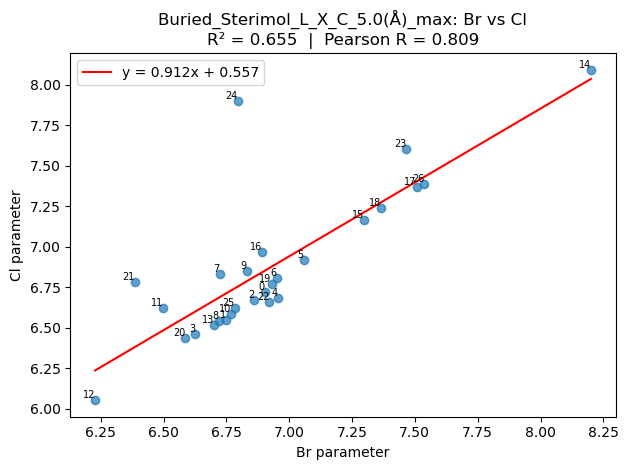

Low-correlation feature: Buried_Sterimol_L_X_C_5.0(Å)_low_E  (R = 0.847)


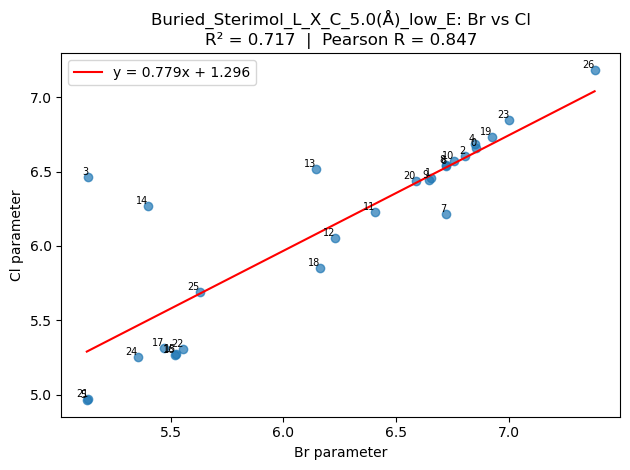

Low-correlation feature: pyramidalization_Gavrish_C(°)_min  (R = 0.943)


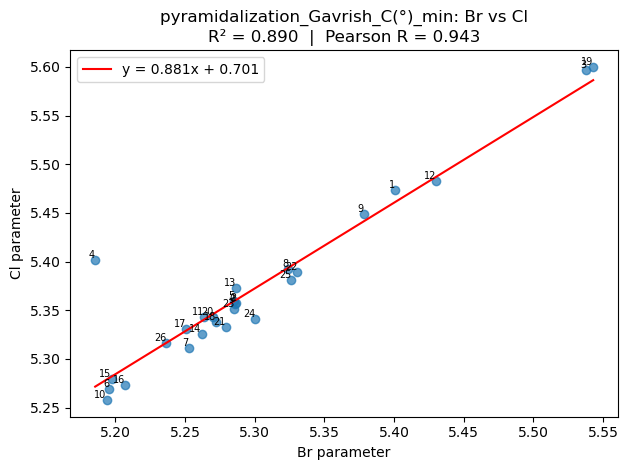

Low-correlation feature: pyramidalization_Agranat-Radhakrishnan_C_min  (R = 0.942)


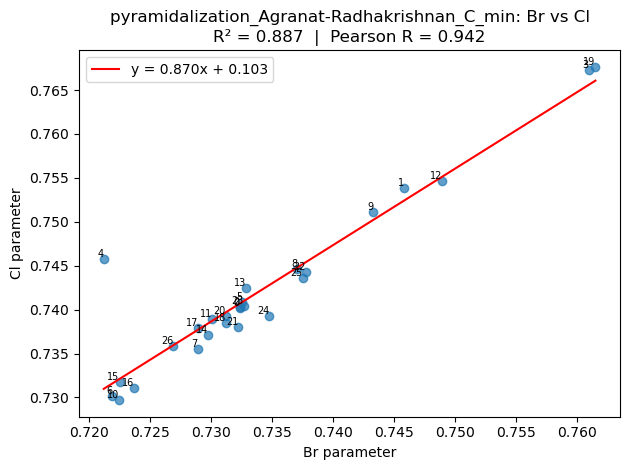

Low-correlation feature: ChelpG_charge_C_min  (R = 0.948)


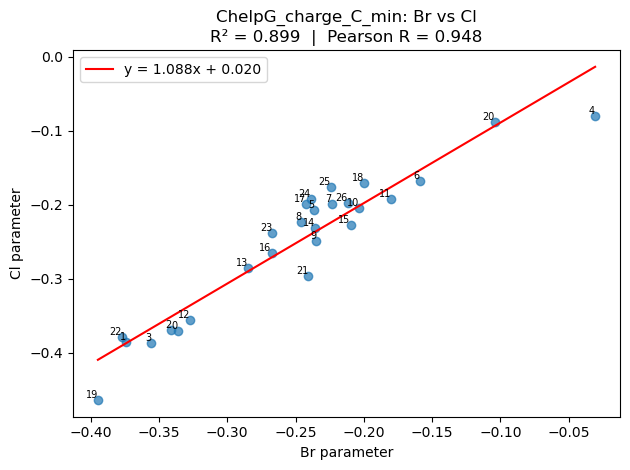

Low-correlation feature: ChelpG_charge_C_low_E  (R = 0.948)


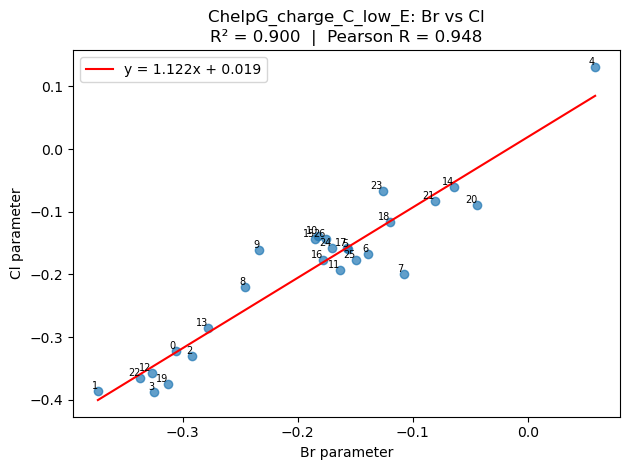

Low-correlation feature: ChelpG_charge_X_low_E  (R = 0.924)


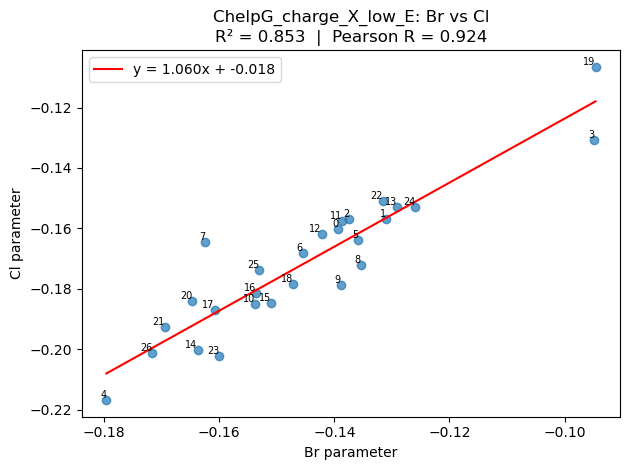

Low-correlation feature: Hirsh_CM5_charge_C_Boltz  (R = 0.917)


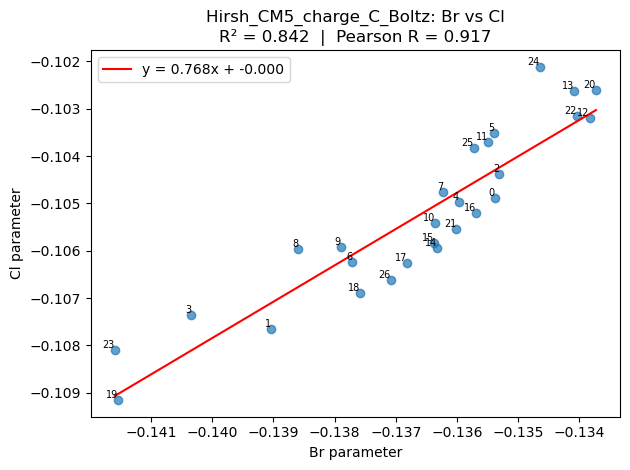

Low-correlation feature: Hirsh_CM5_charge_C_low_E  (R = 0.804)


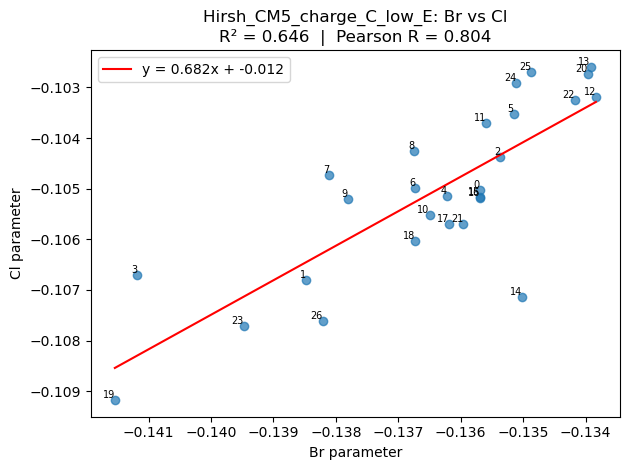

Low-correlation feature: Hirsh_atom_dipole_C_Boltz  (R = 0.880)


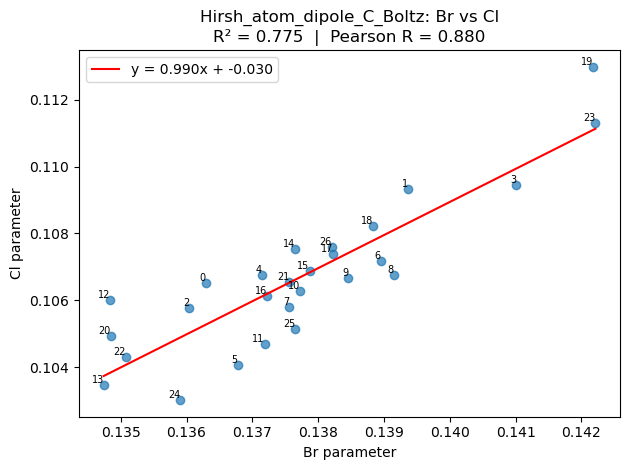

Low-correlation feature: Hirsh_atom_dipole_C_min  (R = 0.918)


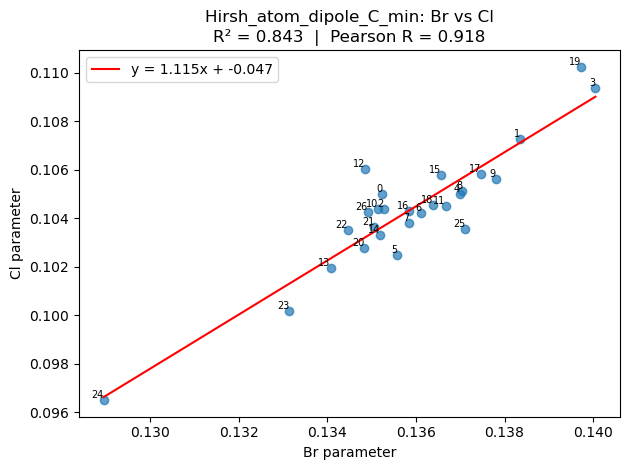

Low-correlation feature: Hirsh_atom_dipole_C_max  (R = 0.933)


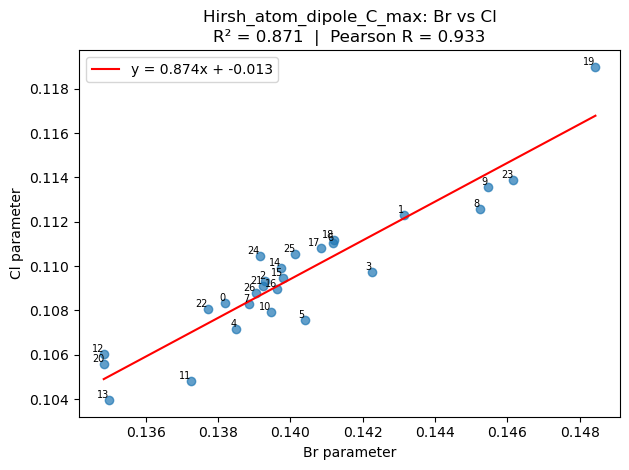

Low-correlation feature: Hirsh_atom_dipole_C_low_E  (R = 0.748)


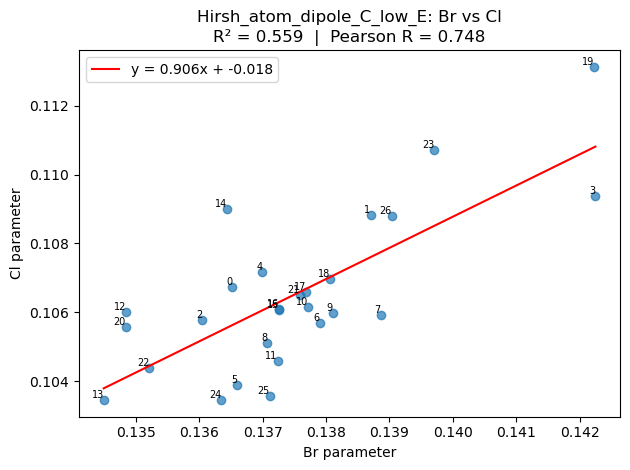

Low-correlation feature: Hirsh_charge_X_low_E  (R = 0.899)


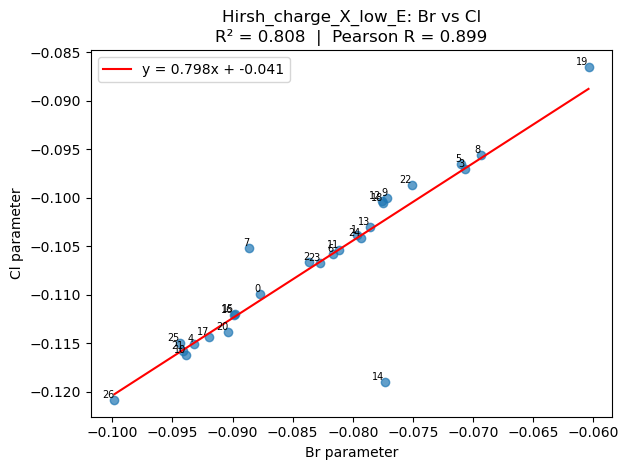

Low-correlation feature: Hirsh_CM5_charge_X_low_E  (R = 0.910)


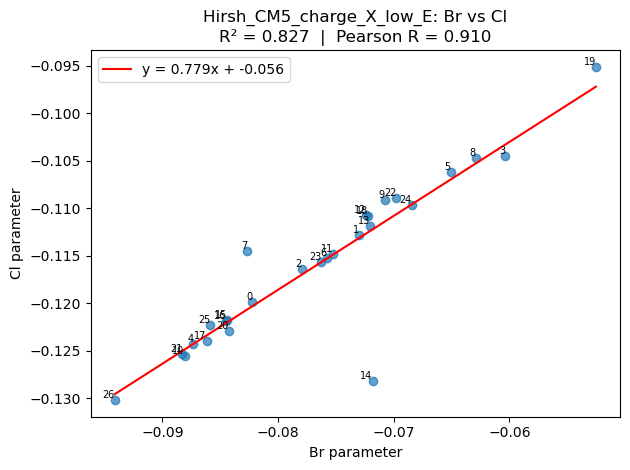

Low-correlation feature: Hirsh_atom_dipole_X_Boltz  (R = 0.943)


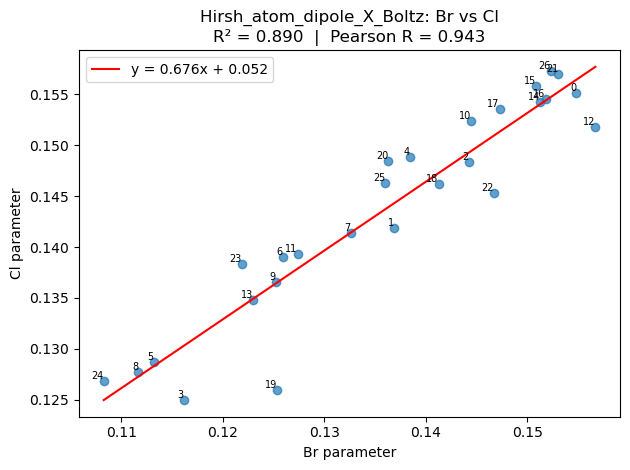

Low-correlation feature: Hirsh_atom_dipole_X_min  (R = 0.922)


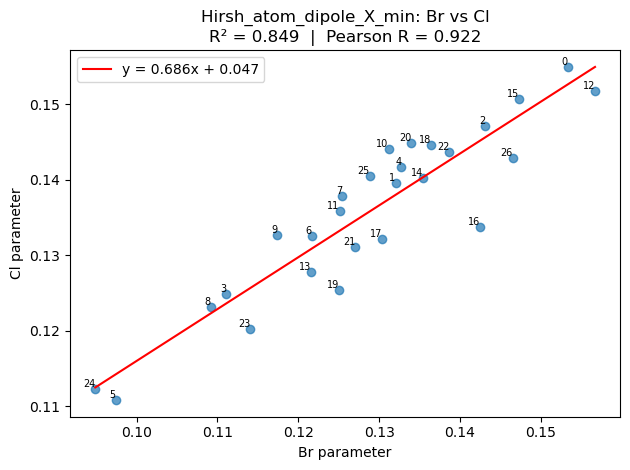

Low-correlation feature: Hirsh_atom_dipole_X_max  (R = 0.896)


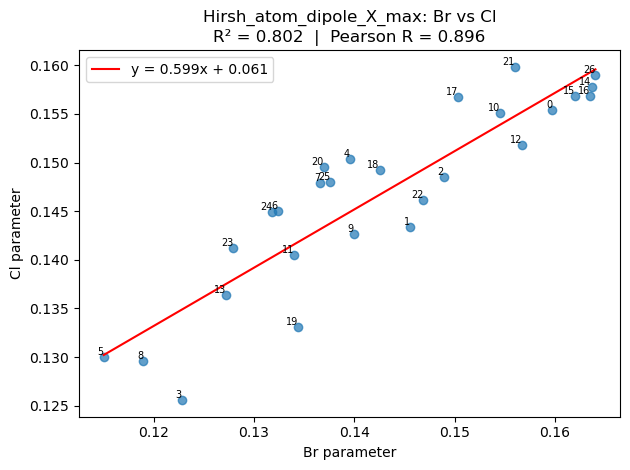

Low-correlation feature: Hirsh_atom_dipole_X_low_E  (R = 0.923)


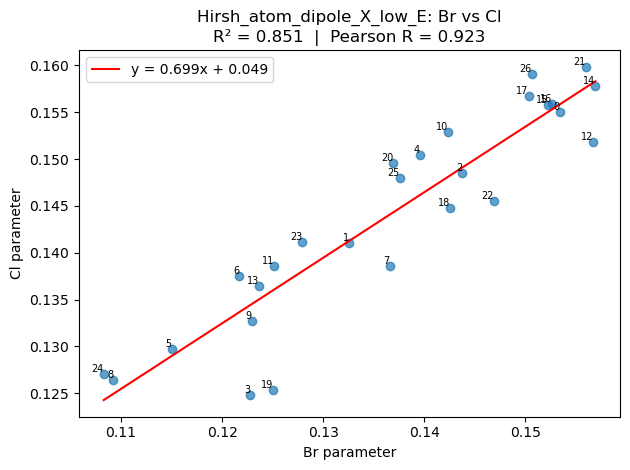

,feature,slope,intercept,R^2,Pearson R,P value,stderr,intercept_stderr
0,HOMO_Boltz,1.320280,0.104052,0.942475,0.970812,5.113095e-17,0.065236,0.022416
1,HOMO_min,1.291872,0.095183,0.941195,0.970152,6.737677e-17,0.064583,0.022341
2,HOMO_max,1.286360,0.092490,0.938579,0.968803,1.162291e-16,0.065814,0.022316
3,HOMO_low_E,1.341188,0.111434,0.936959,0.967966,1.610653e-16,0.069578,0.023934
4,LUMO_Boltz,1.452735,-0.013647,0.927768,0.963207,8.866987e-16,0.081070,0.005164
...,...,...,...,...,...,...,...,...
171,Hirsh_CM5_charge_X_low_E,0.778600,-0.056306,0.827324,0.909573,5.033824e-11,0.071141,0.005483
172,Hirsh_atom_dipole_X_Boltz,0.675749,0.051800,0.889736,0.943258,1.788255e-13,0.047577,0.006508
173,Hirsh_atom_dipole_X_min,0.686102,0.047404,0.849183,0.921511,9.161040e-12,0.057829,0.007501
174,Hirsh_atom_dipole_X_max,0.599286,0.061287,0.802107,0.895604,2.805405e-10,0.059534,0.008528


In [5]:
PLOT_THRESHOLD = 0.95
skip_cols_alkyl = {'id', 'smiles', 'numeric_id'}
records = []

for col in df_br.columns:
    if col in skip_cols_alkyl:
        continue
    res = stats.linregress(df_br[col], df_cl[col])
    records.append({
        'feature':          col,
        'slope':            res.slope,
        'intercept':        res.intercept,
        'R^2':              res.rvalue ** 2,
        'Pearson R':        res.rvalue,
        'P value':          res.pvalue,
        'stderr':           res.stderr,
        'intercept_stderr': res.intercept_stderr,
    })

    if abs(res.rvalue) < PLOT_THRESHOLD:
        print(f"Low-correlation feature: {col}  (R = {res.rvalue:.3f})")
        fig, ax = plt.subplots()
        ax.scatter(df_br[col], df_cl[col], alpha=0.7)
        x_line = np.linspace(df_br[col].min(), df_br[col].max(), 100)
        ax.plot(x_line, res.slope * x_line + res.intercept, 'r',
                label=f'y = {res.slope:.3f}x + {res.intercept:.3f}')
        for j in df_br.index:
            ax.text(df_br.loc[j, col], df_cl.loc[j, col], str(j),
                    fontsize=7, ha='right', va='bottom')
        ax.set(title=f'{col}: Br vs Cl\nR² = {res.rvalue**2:.3f}  |  Pearson R = {res.rvalue:.3f}',
               xlabel='Br parameter', ylabel='Cl parameter')
        ax.legend()
        plt.tight_layout()
        plt.show()

correction_term_df = pd.DataFrame(records)
correction_term_df.to_excel('./alkyl/output/correction_factor_information_alkcl_alkbr.xlsx', index=False)
display(correction_term_df)

### Filter to High-Correlation Features (Pearson R > 0.95)

In [9]:
correction_term_df = pd.read_excel(
    './alkyl/output/correction_factor_information_alkcl_alkbr.xlsx', index_col=0)

high_corr_df = correction_term_df[correction_term_df['Pearson R'] >  0.95]
low_corr_df  = correction_term_df[correction_term_df['Pearson R'] <= 0.95]

print(f"High-correlation features (R > 0.95): {len(high_corr_df)}")
print(f"Low-correlation features  (R ≤ 0.95): {len(low_corr_df)}")
print(f"Low-correlation feature names: {low_corr_df.index.tolist()}")  

display(high_corr_df)

high_corr_feats = high_corr_df.index.tolist()  

High-correlation features (R > 0.95): 135
Low-correlation features  (R ≤ 0.95): 41
Low-correlation feature names: ['μ_Boltz', 'μ_min', 'μ_max', 'μ_low_E', 'ω_min', 'polar_aniso(Debye)_low_E', 'dipole(Debye)_low_E', 'volume(Bohr_radius³/mol)_Boltz', 'volume(Bohr_radius³/mol)_min', 'volume(Bohr_radius³/mol)_max', 'volume(Bohr_radius³/mol)_low_E', 'NBO_charge_X_low_E', 'NMR_shift_X_low_E', '%Vbur_C_2.0Å_max', '%Vbur_X_2.0Å_low_E', '%Vbur_X_2.5Å_low_E', '%Vbur_X_3.0Å_low_E', '%Vbur_X_3.5Å_low_E', '%Vbur_X_4.0Å_low_E', 'Sterimol_L_X_C(Å)_morfeus_low_E', 'Buried_Sterimol_L_C_X_5.0(Å)_Boltz', 'Buried_Sterimol_B5_C_X_5.0(Å)_low_E', 'Buried_Sterimol_L_X_C_5.0(Å)_max', 'Buried_Sterimol_L_X_C_5.0(Å)_low_E', 'pyramidalization_Gavrish_C(°)_min', 'pyramidalization_Agranat-Radhakrishnan_C_min', 'ChelpG_charge_C_min', 'ChelpG_charge_C_low_E', 'ChelpG_charge_X_low_E', 'Hirsh_CM5_charge_C_Boltz', 'Hirsh_CM5_charge_C_low_E', 'Hirsh_atom_dipole_C_Boltz', 'Hirsh_atom_dipole_C_min', 'Hirsh_atom_dipole_C_max

,slope,intercept,R^2,Pearson R,P value,stderr,intercept_stderr
feature,,,,,,,
HOMO_Boltz,1.320280,0.104052,0.942475,0.970812,5.113095e-17,0.065236,0.022416
HOMO_min,1.291872,0.095183,0.941195,0.970152,6.737677e-17,0.064583,0.022341
HOMO_max,1.286360,0.092490,0.938579,0.968803,1.162291e-16,0.065814,0.022316
HOMO_low_E,1.341188,0.111434,0.936959,0.967966,1.610653e-16,0.069578,0.023934
LUMO_Boltz,1.452735,-0.013647,0.927768,0.963207,8.866987e-16,0.081070,0.005164
...,...,...,...,...,...,...,...
Hirsh_charge_X_min,0.881698,-0.033310,0.989904,0.994939,1.788450e-26,0.017808,0.001556
Hirsh_charge_X_max,0.897882,-0.031082,0.982743,0.991334,1.459979e-23,0.023797,0.001673
Hirsh_CM5_charge_X_Boltz,0.854594,-0.050221,0.987850,0.993906,1.812638e-25,0.018955,0.001442


### Predict Alkyl Cl Properties for the Full Library

In [11]:
df_br_lib = pd.read_excel('./molecular_descriptors.xlsx', sheet_name='alkylBrlib')

# Drop variance columns
stdev_cols = list(df_br_lib.filter(like='_stdev').columns)
range_cols  = list(df_br_lib.filter(like='_range').columns)
df_br_lib   = df_br_lib.drop(columns=stdev_cols + range_cols)

# Restrict to high-correlation features that exist in the library
available      = set(df_br_lib.columns)
feats_filtered = [f for f in high_corr_feats if f in available]
missing        = set(high_corr_feats) - set(feats_filtered)
if missing:
    print(f"Warning: {len(missing)} feature(s) absent from library and skipped: {missing}")

df_br_lib = df_br_lib[['id', 'smiles'] + feats_filtered]
df_br_lib.to_excel('./alkyl/output/primary_alkylbr_lib_high_corr_feat.xlsx', index=False)

# Apply linear correction factors
def apply_correction_alkyl(df, lookup, skip_cols):
    df = df.copy()
    for feat in df.columns:
        if feat in skip_cols:
            continue
        if feat not in lookup.index:
            print(f"Skipping '{feat}' — no correction factor found.")
            continue
        m = lookup.loc[feat, 'slope']
        b = lookup.loc[feat, 'intercept']
        df[feat] = m * df[feat] + b
    return df

df_cl_lib = apply_correction_alkyl(df_br_lib, correction_term_df,  # ← pass directly, already indexed
                                    skip_cols={'id', 'smiles'})

# Add Cl-specific ID and convert SMILES
df_cl_lib['alkCl_id'] = df_cl_lib['id'].str.replace('mol', 'molCl', regex=False)
df_cl_lib.rename(columns={'id': 'alkBr_id'}, inplace=True)

pattern     = Chem.MolFromSmiles('Br')
replacement = Chem.MolFromSmiles('Cl')

def br_to_cl_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mol = Chem.ReplaceSubstructs(mol, pattern, replacement)[0]
        return Chem.MolToSmiles(mol)
    return smi

df_cl_lib['alkCl_smiles'] = df_cl_lib['smiles'].apply(br_to_cl_smiles)
df_cl_lib.rename(columns={'smiles': 'alkBr_smiles'}, inplace=True)

df_cl_lib.to_excel(
    './alkyl/output/predicted_alkylCl_properties_from_alkylBr_lib.xlsx',
    index=False)
print(f"Exported {len(df_cl_lib)} rows to predicted_alkylCl_properties_from_alkylBr_lib.xlsx")
display(df_cl_lib.head())

C:\Users\haruk\AppData\Local\Temp\ipykernel_26548\1865851929.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cl_lib['alkCl_id'] = df_cl_lib['id'].str.replace('mol', 'molCl', regex=False)
C:\Users\haruk\AppData\Local\Temp\ipykernel_26548\1865851929.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cl_lib['alkCl_smiles'] = df_cl_lib['smiles'].apply(br_to_cl_smiles)


Exported 879 rows to predicted_alkylCl_properties_from_alkylBr_lib.xlsx


,alkBr_id,alkBr_smiles,HOMO_Boltz,HOMO_min,HOMO_max,HOMO_low_E,LUMO_Boltz,LUMO_min,LUMO_max,LUMO_low_E,...,Hirsh_CM5_charge_C_min,Hirsh_CM5_charge_C_max,Hirsh_charge_X_Boltz,Hirsh_charge_X_min,Hirsh_charge_X_max,Hirsh_CM5_charge_X_Boltz,Hirsh_CM5_charge_X_min,Hirsh_CM5_charge_X_max,alkCl_id,alkCl_smiles
0,mol094,BrCC1(CC#N)CC1,-0.383047,-0.384412,-0.378215,-0.382257,0.070698,0.068568,0.071232,0.072383,...,-0.101218,-0.097848,-0.100270,-0.100802,-0.069666,-0.109488,-0.109815,-0.080244,molCl094,N#CCC1(CCl)CC1
1,mol095,BrCC1(CC1)C#N,-0.386285,-0.387990,-0.384917,-0.386321,0.064864,0.048695,0.065795,0.067246,...,-0.096527,-0.092973,-0.087785,-0.089984,-0.062013,-0.096191,-0.097968,-0.072526,molCl095,N#CC1(CCl)CC1
2,mol097,BrCC1(CCCC1)C#N,-0.384479,-0.386686,-0.381148,-0.388172,0.063927,0.054116,0.071367,0.053122,...,-0.100029,-0.096203,-0.077925,-0.081733,-0.059677,-0.087506,-0.090023,-0.070164,molCl097,N#CC1(CCl)CCCC1
3,mol098,BrCC1(CCCC1)c1ccccc1,-0.324853,-0.330050,-0.318888,-0.322937,0.059836,0.047823,0.063414,0.064996,...,-0.104511,-0.101570,-0.099984,-0.104196,-0.083070,-0.109351,-0.112672,-0.094375,molCl098,ClCC1(c2ccccc2)CCCC1
4,mol099,BrCC1(CN2C(=O)c3ccccc3C2=O)OCCO1,-0.344850,-0.345630,-0.336949,-0.344583,-0.052308,-0.046675,-0.046567,-0.050024,...,-0.111398,-0.107076,-0.094119,-0.097064,-0.082331,-0.099885,-0.102229,-0.086326,molCl099,O=C1c2ccccc2C(=O)N1CC1(CCl)OCCO1
